In [1]:
import polars as pl
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import math
import itertools
from procompa import get_project_root, get_data_dir

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"
data_dir_YM = get_data_dir() / "26.03_yeast.MAP"

## Understand pooled data

In [ ]:
import af3io, pooled_ppi

In [ ]:
pp = pooled_ppi.PooledPredictionsDb("/cluster/work/beltrao/jjaenes/25.12_pooled-ppi-yeast/data-26.04")
pairs_ = pp.pairs.query('uniprot_id1 in @proteins & uniprot_id2 in @proteins').sort_values('af3_pair').reset_index(drop=True)


Select High confidence Score

In [3]:
YM_COMPLEX_overlap = pl.read_csv(data_dir /"Complex_Portal/YeastMap/complex_db_complete_unique_overlap_complex_yeastmap_by_complex.csv")
complex_db_entries = pl.read_csv(data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator= "\t" )

In [4]:
#firstly focus on predition taht have an extremly high confidence score of 1
#high_confidence_predictions = YM_COMPLEX_overlap.filter(pl.col("ComplexConfidence") == 1)

#add stoichiometry information from complex database (if given)
YM_COMPLEX_overlap = (
    YM_COMPLEX_overlap.join(
        complex_db_entries.select([
            "#Complex ac", 
            "Identifiers (and stoichiometry) of molecules in complex"
        ]),
        on="#Complex ac",
        how="left"
    )
    .with_columns(
        stoichiometry_known = ~pl.col("Identifiers (and stoichiometry) of molecules in complex").str.contains(r"\(0\)"),
        solely_proteins = ~pl.col("Identifiers (and stoichiometry) of molecules in complex").str.contains(r":")
    )
)

for which homdimers do i have the pdb file

In [6]:
homodimer_with_pdb = pl.read_csv(data_dir/ "Pipeline/homodimer_pdb_files/merged_pdbs/pdb_file_names.csv")

In [ ]:
homodimer_set = homodimer_with_pdb["uniprot_id_homodimer"].to_list()

YM_COMPLEX_overlap = YM_COMPLEX_overlap.with_columns(
    pl.col("true_complex").str.split(" ").alias("_proteins")
).with_columns(
    pl.col("_proteins")
      .list.eval(pl.element().is_in(homodimer_set))
      .list.sum()
      .alias("n_proteins_with_homodimer_pdb"),
    pl.col("_proteins")
      .list.eval(pl.element().is_in(homodimer_set))
      .list.all()
      .alias("all_proteins_have_pdb"),
).drop("_proteins")

strict pipeline dataset for complexes where all proteins have homodimers on Alfafold database

In [ ]:
pdb_pipeline_dataset = YM_COMPLEX_overlap.filter((pl.col("solely_proteins") == True)& (pl.col("stoichiometry_known") == True)& pl.col("all_proteins_have_pdb")== True)

In [ ]:
pdb_pipeline_dataset.write_csv(data_dir/ "Pipeline/pdb_present_first_setup_pipeline_complexes.csv")

initial first subset for the pipeline

In [ ]:
pipeline_complexes = high_confidence_predictions.filter((pl.col("solely_proteins") == True)& (pl.col("stoichiometry_known") == True)& (pl.col("jaccard_similarity") == 1))

In [ ]:
pipeline_complexes.write_csv(data_dir/ "Pipeline/first_setup_pipeline_complexes.csv")

In [ ]:
uniprot_id_complexes_pipeline = pipeline_complexes.get_column("predicted_complex").str.split(" " ).explode().unique().to_list()

#pl.DataFrame({"uniprot_id": uniprot_id_complexes_pipeline}).write_csv(data_dir /"Pipeline/uniprot_ids_first_setup.csv")

## cretae subset for combfold where i have pdb files for all proteins in the complex to understand when it assembles and wen it doenst

In [ ]:
YM_COMPLEX_overlap_homomerdimer_pdb = YM_COMPLEX_overlap.filter((pl.col("all_proteins_have_pdb") == True) &(pl.col("stoichiometry_known")))#YM_COMPLEX_overlap based on homodimers for whcih i have pdb and cell beforehand

In [ ]:
YM_COMPLEX_overlap_homomerdimer_pdb = YM_COMPLEX_overlap_homomerdimer_pdb.with_columns(
    comb_fold_submission = pl.col("Identifiers (and stoichiometry) of molecules in complex")
    .str.split("|")                                 
    .list.filter(~pl.element().str.starts_with("CHEBI:"))  
    .list.join(",")                                  
)

In [58]:
YM_COMPLEX_overlap_homomerdimer_pdb = pl.read_csv(data_dir / "Pipeline/first_setup/all_pdb_present_first_setup_pipeline_complexes.csv")

In [59]:
YM_COMPLEX_overlap_homomerdimer_pdb = (
    YM_COMPLEX_overlap_homomerdimer_pdb
    .sort("jaccard_similarity", descending=True)
    .group_by("true_complex")
    .first()
)

In [60]:
YM_COMPLEX_overlap_homomerdimer_pdb.write_csv(data_dir/ "Pipeline/first_setup/all_pdb_present_first_setup_pipeline_complexes.csv")

## Get iptm scores for all pairs

homodimers (iptm scores based on Gummis downloded adata from the alpfa fold database, pdb files are >NOT present for all of these (only around 700 of the 6000))

In [ ]:
download_manifest_17_06_26 = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/afdb_pdbs_17_06_26/download_manifest.csv")

download_manifest_01_04_266 = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/afdb_pdbs_01_04_26/download_manifest.csv")

merged_download_manifest = (
    pl.concat([download_manifest_17_06_26, download_manifest_01_04_266])
    .unique(subset="uniprotAccession", keep="first")
)
merged_download_manifest["uniprotAccession","ipTM"].write_csv("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/merged_pdbs/homodimer_iptm.csv")

Heterodimer: get all yeast pairs from YM and complex combinations

In [3]:
#get pair between all yeast proteins
yeast_MAP_complexes_wConfidenceScores_wGenenames_total779_20251214 = pl.read_csv(
    data_dir_YM / "yeast.MAP_complexes_wConfidenceScores_wGenenames_total779_20251214.csv", separator = ",", has_header = True)

complex_db_entries = pl.read_csv(data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator= "\t" )

In [ ]:
unique_ym_prot = (
    yeast_MAP_complexes_wConfidenceScores_wGenenames_total779_20251214
    .select(pl.col("UniProt_ACCs").str.split(" "))
    .explode("UniProt_ACCs")
    .get_column("UniProt_ACCs")
    .unique()
    .to_list()
)


col = "Identifiers (and stoichiometry) of molecules in complex"

unique_complex_db_entries = (
    complex_db_entries
    .select(
        # 1) remove brackets [ ]
        pl.col(col).str.replace_all(r"[\[\]]", "")
        # 2) Convert all pipes '|' into commas ',' 
        .str.replace_all(r"\|", ",")
        # 3) Now we can safely split on a literal comma!
        .str.split(",")
    )
    .explode(col)
    # 4) remove stoichiometry (x)
    .with_columns(
        pl.col(col)
        .str.replace_all(r"\(\d+\)", "")
        .str.strip_chars()
    )
    # 5) drop CHEBI entries and empty records
    .filter(~pl.col(col).str.starts_with("CHEBI:"))
    .filter(pl.col(col) != "")
    .get_column(col)
    .unique()
    .to_list()
)

In [23]:
all_yeast_prot = list(set(unique_complex_db_entries).union(unique_ym_prot))
#generate all possible pairs
protein_pairs = list(itertools.combinations(all_yeast_prot, 2))


In [ ]:
pairs_df = pl.DataFrame(
    protein_pairs, 
    schema=["protein_A", "protein_B"],
    orient="row"
)

pairs_df.write_parquet(data_dir/"iPTM/yeast_protein_pairs.parquet")

after running script 08_lookup_iptm.sh i get yeast_pairs_iptm_mapped.parquet (based on pooled AF data)
now I can combine the data so i have iptm scores for all pairs (homo- and heterodimers)

In [51]:
heterodimer_iptm = pl.read_parquet(data_dir/"iPTM/yeast_pairs_iptm_mapped.parquet")
homodimer_iptm = pl.read_csv(data_dir/"iPTM/homodimer_iptm.csv")

In [52]:
#add info whether it is hetero/homodimer
heterodimer_iptm = heterodimer_iptm.with_columns(
    dimer = pl.lit("heterodimer")
)

#adjust format so it matches heterodimer_iptm df
homodimer_iptm = (
    homodimer_iptm.with_columns(
    dimer = pl.lit("homodimer"),
    protein_A = pl.col("uniprotAccession"),
    protein_B = pl.col("uniprotAccession")
    )
    .drop("uniprotAccession")
    .rename({"ipTM": "best_iptm"})
    .select(['protein_A', 'protein_B', 'best_iptm', 'dimer'])
)

# Stack them vertically
#combined_iptm = pl.concat([heterodimer_iptm, homodimer_iptm]).write_parquet(data_dir / "iPTM/all_YM_complex_yeast_pairs_iptm.parquet")

## Check second setup results

In [2]:
second_setup_results = pl.read_csv(data_dir / "Pipeline/second_setup/all_pdb_present_second_setup_pipeline_complexes_combfold_results.csv")

In [3]:
input_second_setup = pl.read_csv(data_dir / "Pipeline/first_setup/all_pdb_present_first_setup_pipeline_complexes.csv")

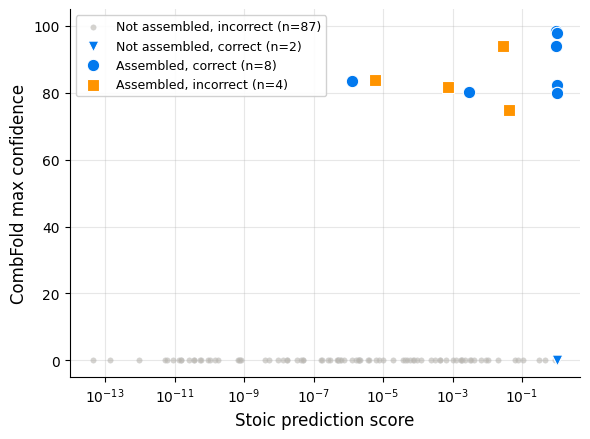

In [25]:
# --- Parse max confidence from confidence_scores column ---
def parse_max_conf(conf_str):
    if not isinstance(conf_str, str) or not conf_str:
        return None
    scores = []
    for part in conf_str.split(";"):
        try:
            scores.append(float(part.split(":")[1]))
        except:
            pass
    return max(scores) if scores else None

second_setup_results = second_setup_results.with_columns(pl.Series("max_confidence", [parse_max_conf(r) for r in second_setup_results["confidence_scores"].to_list()]))

# --- Figure 3: Stoic Score vs CombFold Confidence Scatter ---
assembled = second_setup_results.filter(pl.col("combfold_successfully"))
not_assembled = second_setup_results.filter(~pl.col("combfold_successfully"))

correct_asm = assembled.filter(pl.col("stoic_pred_correct"))
incorrect_asm = assembled.filter(~pl.col("stoic_pred_correct"))
correct_not_asm = not_assembled.filter(pl.col("stoic_pred_correct"))
incorrect_not_asm = not_assembled.filter(~pl.col("stoic_pred_correct"))

fig, ax = plt.subplots(figsize=(6, 4.5))

# Not assembled, incorrect: small grey dots at y=0
ax.scatter(
    incorrect_not_asm["pred_score"].to_list(),
    [0] * len(incorrect_not_asm),
    s=15, alpha=0.6, color="#B9B6AF", edgecolors="#CCCCCC", linewidths=0.5,
    label=f"Not assembled, incorrect (n={len(incorrect_not_asm)})", zorder=1,
)

# Not assembled, correct: blue triangles at y=0
ax.scatter(
    correct_not_asm["pred_score"].to_list(),
    [0] * len(correct_not_asm),
    s=60, color="#0279EE", marker="v", edgecolors="white", linewidths=0.8,
    label=f"Not assembled, correct (n={len(correct_not_asm)})", zorder=2,
)

# Assembled: colored by correctness
ax.scatter(
    correct_asm["pred_score"].to_list(),
    correct_asm["max_confidence"].to_list(),
    s=80, color="#0279EE", marker="o", edgecolors="white", linewidths=0.8,
    label=f"Assembled, correct (n={len(correct_asm)})", zorder=3,
)

ax.scatter(
    incorrect_asm["pred_score"].to_list(),
    incorrect_asm["max_confidence"].to_list(),
    s=80, color="#FF9400", marker="s", edgecolors="white", linewidths=0.8,
    label=f"Assembled, incorrect (n={len(incorrect_asm)})", zorder=3,
)

ax.set_xscale("log")
ax.set_xlabel("Stoic prediction score", fontsize=12)
ax.set_ylabel("CombFold max confidence", fontsize=12)
ax.set_ylim(-5, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper left", framealpha=0.9)

plt.tight_layout()
#save the plot
plt.savefig(data_dir/"Pipeline/second_setup/stoic_CF_performance.png", dpi=500, bbox_inches="tight")
plt.show()

## create third setup

coplexes where i have homodimer pdb if the correct stoi is bigger 2, but not necessarily need stoichiometry for other proteins

In [2]:
YM_COMPLEX_overlap = pl.read_csv(
    data_dir / "Complex_Portal/YeastMap/complex_db_complete_unique_overlap_complex_yeastmap_by_complex.csv"
)
complex_db_entries = pl.read_csv(
    data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv",
    separator="	",
)
homodimer_with_pdb = pl.read_csv(
    data_dir / "Pipeline/homodimer_pdb_files/merged_pdbs/pdb_file_names.csv"
)
homodimer_set = set(homodimer_with_pdb["uniprot_id_homodimer"].to_list())

# --- Helpers ---
def _parse_proteins(s):
    if not isinstance(s, str) or not s:
        return []
    return re.findall(r"([A-Za-z0-9_]+)\(\d+\)", s)

def _parse_counts(s):
    if not isinstance(s, str) or not s:
        return []
    return [int(x) for x in re.findall(r"[A-Za-z0-9_]+\((\d+)\)", s)]

def _proteins_with_pdb(s):
    if not isinstance(s, str) or not s:
        return ""
    return ", ".join(p for p in s.split(" ") if p in homodimer_set)

def _pdb_for_true_stoi(stoich_str):
    if not isinstance(stoich_str, str) or not stoich_str:
        return False
    proteins = _parse_proteins(stoich_str)
    counts = _parse_counts(stoich_str)
    if not proteins:
        return False
    return all(
        (cnt < 2) or (prot in homodimer_set)
        for prot, cnt in zip(proteins, counts)
    )

# --- Add stoichiometry info from Complex Portal ---
YM_COMPLEX_overlap = (
    YM_COMPLEX_overlap.join(
        complex_db_entries.select([
            "#Complex ac",
            "Identifiers (and stoichiometry) of molecules in complex",
        ]),
        on="#Complex ac",
        how="left",
    )
    .with_columns(
        stoichiometry_known=(
            pl.col("Identifiers (and stoichiometry) of molecules in complex").is_not_null()
            & ~pl.col("Identifiers (and stoichiometry) of molecules in complex").str.contains(r"\(0\)")
        ),
        solely_proteins=(
            pl.col("Identifiers (and stoichiometry) of molecules in complex").is_not_null()
            & ~pl.col("Identifiers (and stoichiometry) of molecules in complex").str.contains(r":")
        ),
        comb_fold_submission=(
            pl.col("Identifiers (and stoichiometry) of molecules in complex")
            .str.split("|")
            .list.filter(~pl.element().str.starts_with("CHEBI:"))
            .list.filter(~pl.element().str.contains(r"\(0\)"))
            .list.join(",")
        ),
    )
)

# --- Determine CombFold feasibility ---
YM_COMPLEX_overlap = YM_COMPLEX_overlap.with_columns(
    proteins_with_homodimer_pdb=pl.col("true_complex").map_elements(
        _proteins_with_pdb, return_dtype=pl.Utf8,
    ),
    pdb_for_true_stoi=pl.col("comb_fold_submission").map_elements(
        _pdb_for_true_stoi, return_dtype=pl.Boolean,
    ),
)

# --- Filter to complexes where CombFold can run ---
all_pdb_present = YM_COMPLEX_overlap.filter(pl.col("pdb_for_true_stoi"))

In [3]:
all_pdb_present = all_pdb_present.filter(pl.col("stoichiometry_known") == True).sort("jaccard_similarity", descending=True).group_by("true_complex").first()

In [ ]:
#all_pdb_present.write_csv(data_dir / "Pipeline/third_setup/pdb_present_for_stoi_gr_two_third_setup_pipeline_complexes.csv")

## How many proteins do i have in complex, yeast map and combined

In [3]:
YM_COMPLEX_overlap = pl.read_csv(
    data_dir / "Complex_Portal/YeastMap/complex_db_complete_unique_overlap_complex_yeastmap_by_complex.csv"
)
complex_db_entries = pl.read_csv(
    data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv",
    separator="	",
)

homodimer_with_pdb = pl.read_csv(
    data_dir / "Pipeline/homodimer_pdb_files/merged_pdbs/pdb_file_names.csv"
)

In [ ]:
YM_proteins = set(
    YM_COMPLEX_overlap["predicted_complex"].str.split(" ").explode().unique().to_list()
)

col = "Identifiers (and stoichiometry) of molecules in complex"
complex_proteins = set(
    complex_db_entries
    .select(
        pl.col(col).str.replace_all(r"[\[\]]", "")
        .str.replace_all(r"\|", ",")
        .str.split(",")
    )
    .explode(col)
    .with_columns(
        pl.col(col).str.replace_all(r"\(\d+\)", "").str.strip_chars()
    )
    .filter(~pl.col(col).str.starts_with("CHEBI:"))
    .filter(pl.col(col) != "")
    .filter(~pl.col(col).str.contains("CPX"))
    .get_column(col)
    .unique()
    .to_list()
)

homodimer_set = set(homodimer_with_pdb["uniprot_id_homodimer"].to_list())

# --- Table ---
def fmt(n_hom, total):
    return f"{n_hom} ({n_hom / total * 100:.1f}%)"

YM_n = len(YM_proteins)
YM_hom = len(YM_proteins & homodimer_set)

CP_n = len(complex_proteins)
CP_hom = len(complex_proteins & homodimer_set)

ALL_n = len(YM_proteins | complex_proteins)
ALL_hom = len((YM_proteins | complex_proteins) & homodimer_set)

table = pl.DataFrame({
    "Source": ["YeastMap", "Complex Portal", "Combined"],
    "Unique proteins": [str(YM_n), str(CP_n), str(ALL_n)],
    "PDB homodimer present": [fmt(YM_hom, YM_n), fmt(CP_hom, CP_n), fmt(ALL_hom, ALL_n)],
})

table

Source,Unique proteins,PDB homodimer present
str,str,str
"""YeastMap""","""2515""","""286 (11.4%)"""
"""Complex Portal""","""2004""","""127 (6.3%)"""
"""Combined""","""2987""","""311 (10.4%)"""


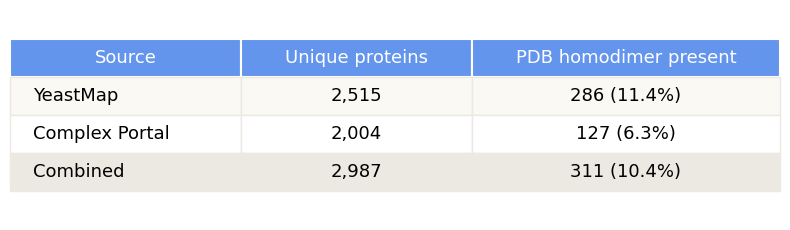

In [14]:
import matplotlib.pyplot as plt

YM_n  = len(YM_proteins);      YM_hom  = len(YM_proteins & homodimer_set)
CP_n  = len(complex_proteins); CP_hom  = len(complex_proteins & homodimer_set)
ALL_n = len(YM_proteins | complex_proteins)
ALL_hom = len((YM_proteins | complex_proteins) & homodimer_set)

def fmt(n_hom, total):
    return f"{n_hom} ({n_hom / total * 100:.1f}%)"

fig, ax = plt.subplots(figsize=(8, 2.4))
ax.axis("off")

cell_text = [
    ["YeastMap",        f"{YM_n:,}",  fmt(YM_hom, YM_n)],
    ["Complex Portal",  f"{CP_n:,}",  fmt(CP_hom, CP_n)],
    ["Combined",        f"{ALL_n:,}", fmt(ALL_hom, ALL_n)],
]
col_labels = ["Source", "Unique proteins", "PDB homodimer present"]

tbl = ax.table(
    cellText=cell_text, colLabels=col_labels,
    cellLoc="center", loc="center",
    colWidths=[0.30, 0.30, 0.40],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1.0, 2.0)

# Header
for j in range(3):
    c = tbl[0, j]
    c.set_facecolor("cornflowerblue")
    c.set_text_props(color="white")
    c.set_edgecolor("white"); c.set_linewidth(1.5)

# Body
for i in range(1, 4):
    for j in range(3):
        c = tbl[i, j]
        c.set_facecolor("#FAF9F3" if i % 2 == 1 else "white")
        c.set_edgecolor("#ECE9E2"); c.set_linewidth(1.0)

# First column left-aligned + bold
for i in range(1, 4):
    tbl[i, 0].set_text_props(ha="left")

# Highlight Combined row
for j in range(3):
    c = tbl[3, j]
    c.set_facecolor("#ECE9E2")


plt.tight_layout()
#plt.savefig("protein_homodimer_table.png", dpi=250, bbox_inches="tight",
           # facecolor="white", pad_inches=0.15)
plt.show()

## other stuff

In [ ]:
yeastmap_complex_pairs_with_scores = pl.read_csv("./Dataframes/Yeast_Map/yeastmap_complex_pairs_with_scores_incl_db.csv")
complex_by_breaking_values = pl.read_csv("./Dataframes/Yeast_Map/complex_by_breaking_values.csv")
YM_pred = pl.read_csv(data_dir_YM / "yeast.MAP_complexes_wConfidenceScores_wGenenames_total779_20251214.csv")
complex_db_entries = pl.read_csv(data_dir / "Complex_Portal/Saccharomyces cerevisiae_ComplexTab.tsv", separator= "\t" )


In [ ]:
YM_pred_with_index = (
    YM_pred.with_row_index("predicted_complex_id", offset = 1)
    .with_columns(
        pl.format("CPX_{}", pl.col("predicted_complex_id")).alias("predicted_complex_id"))
    .rename({"UniProt_ACCs": "predicted_complex"})
)

shoudk have 168 complexes with high confidence scores, for how many of them do I have a complex on COMPLEX (so complete overlap) for how many of the, do i have a stoichioemtry, for how many of them do I have a structure? what is theor iptm score

In [ ]:
pred_high_confidence_list = (YM_pred_with_index.filter(pl.col("ComplexConfidence") == 1).get_column("predicted_complex_id").unique().to_list())

In [ ]:
high_confidence_complex_by_breaking_values = complex_by_breaking_values.filter(pl.col("predicted_complex_id").is_in(pred_high_confidence_list))

In [ ]:
high_confidence_complex_by_breaking_values.height

## Do i have the nexessary AF data to run CF?

In [ ]:
pairs = pl.read_parquet(
    get_data_dir() / "25.12_pooled-ppi-yeast/data-26.03/summary_pairs.parquet"
) #takes around 1 min to load, as confirmed by jürgen the files from 26.04 also do dont contain the self pairs


In [ ]:
self_pairs = pairs.filter(pl.col("af3_id1") == pl.col("af3_id2"))
print(f"Total self-pairs: {self_pairs.height}")
